In [1]:
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
newsgroup = fetch_20newsgroups()

In [2]:
documents = pd.DataFrame({'text': newsgroup.data, 'category': newsgroup.target})


In [3]:
documents = documents.sample(500)
docs = documents.text.to_list()

In [15]:
df = pd.read_csv('/Users/alemeneghini/Dropbox/PHD-Padova/arca/corpora/aborto_twitter.csv')
df = df.sample(5000)
docs = df['text'].to_list()

In [16]:
len(docs)

5000

In [ ]:
from scptm import SCPTM, SCPTMConfig


# Default config

model = SCPTM(num_topics=15, graph_mode='filtered', lang='ita', bow_normalization='tf', keyword_method="ctfidf", random_state=42)
theta = model.fit_transform(docs)

# Topic overview
print(model.get_topic_info())

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7681.03it/s]


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 42.3 MB/s  0:00:00eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('it_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
NLP pipeline: SBERT='paraphrase-multilingual-MiniLM-L12-v2' on cpu, spaCy='it_core_news_sm' on CPU
Loaded 5000 raw documents.
Final corpus: 4906 segments.

[Graph] Mode: 'filtered' — Informative dependency types only (default)
1/5  Building lemma vocabulary...


Lemmatisation: 100%|██████████| 4906/4906 [00:22<00:00, 222.15it/s]
/Users/alemeneghini/Dropbox/stat/CPTM/260521_SCPTM/scptm/.venv/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['gl', 'nient'] not in stop_words.
  warnings.warn(


  Vocabulary: 1668 unique lemmas.
2/5  Encoding documents (SBERT)...


Batches: 100%|██████████| 154/154 [00:38<00:00,  4.02it/s]


...

Dependency parsing: 100%|██████████| 4906/4906 [00:21<00:00, 231.46it/s]


  Syntactic edge distribution:
    nmod        :   4358
    amod        :   2755
    nsubj       :   2524
    conj        :   2010
    xcomp       :    796
    compound    :     71
4/5  Encoding vocabulary (SBERT static)...


Batches: 100%|██████████| 53/53 [00:01<00:00, 32.47it/s]


5/5  Building edge tensors...
  Doc-word edges : 45,616
  Word-word edges: 12,514

[Memory estimate]
  node_features_MB         : 9.6
  edge_index_MB            : 0.4
  activations_MB           : 28.9
  gradients_MB             : 19.3
  total_estimated_GB       : 0.06


Contextual embeddings:  12%|█▏        | 585/4906 [00:13<01:25, 50.50it/s]

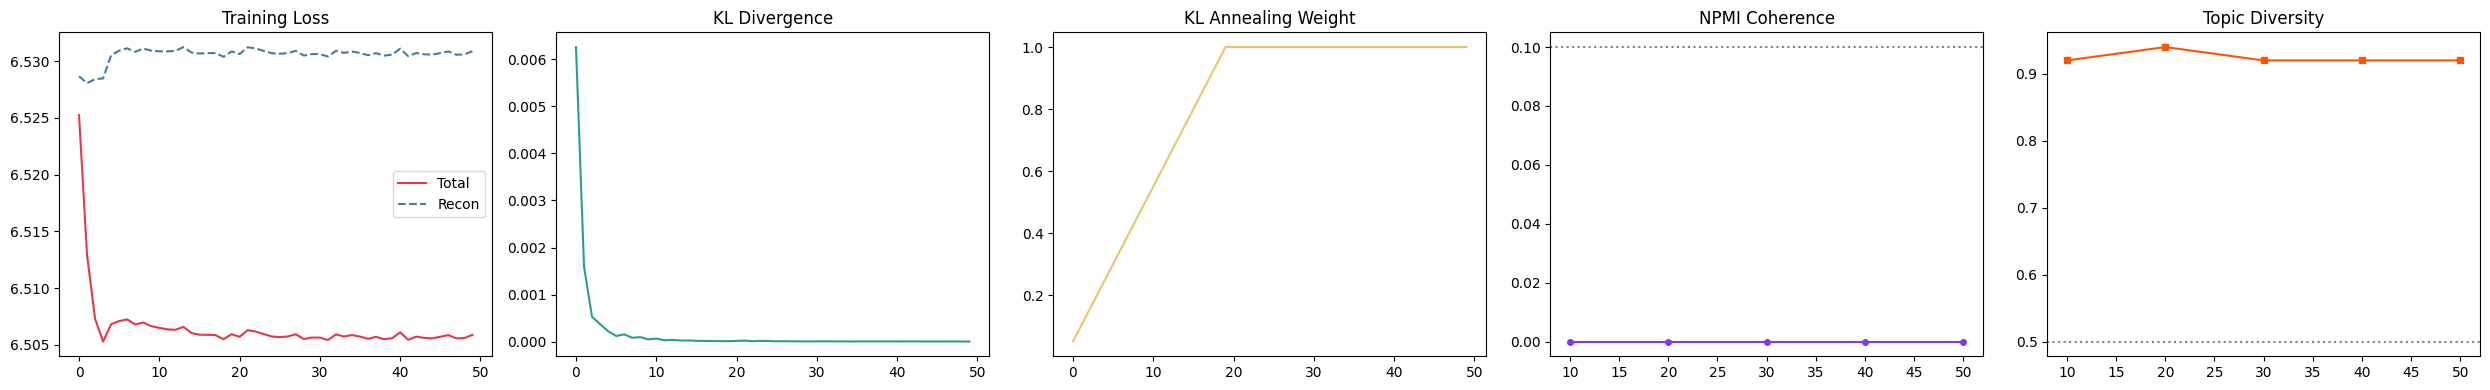

Saved: training_history.png

Extracting single words + MWEs per topic...
Computing 2D UMAP projection...


/Users/alemeneghini/Dropbox/stat/CPTM/260521_SCPTM/scptm/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


High-resolution figure saved: semantic_space_2d.png


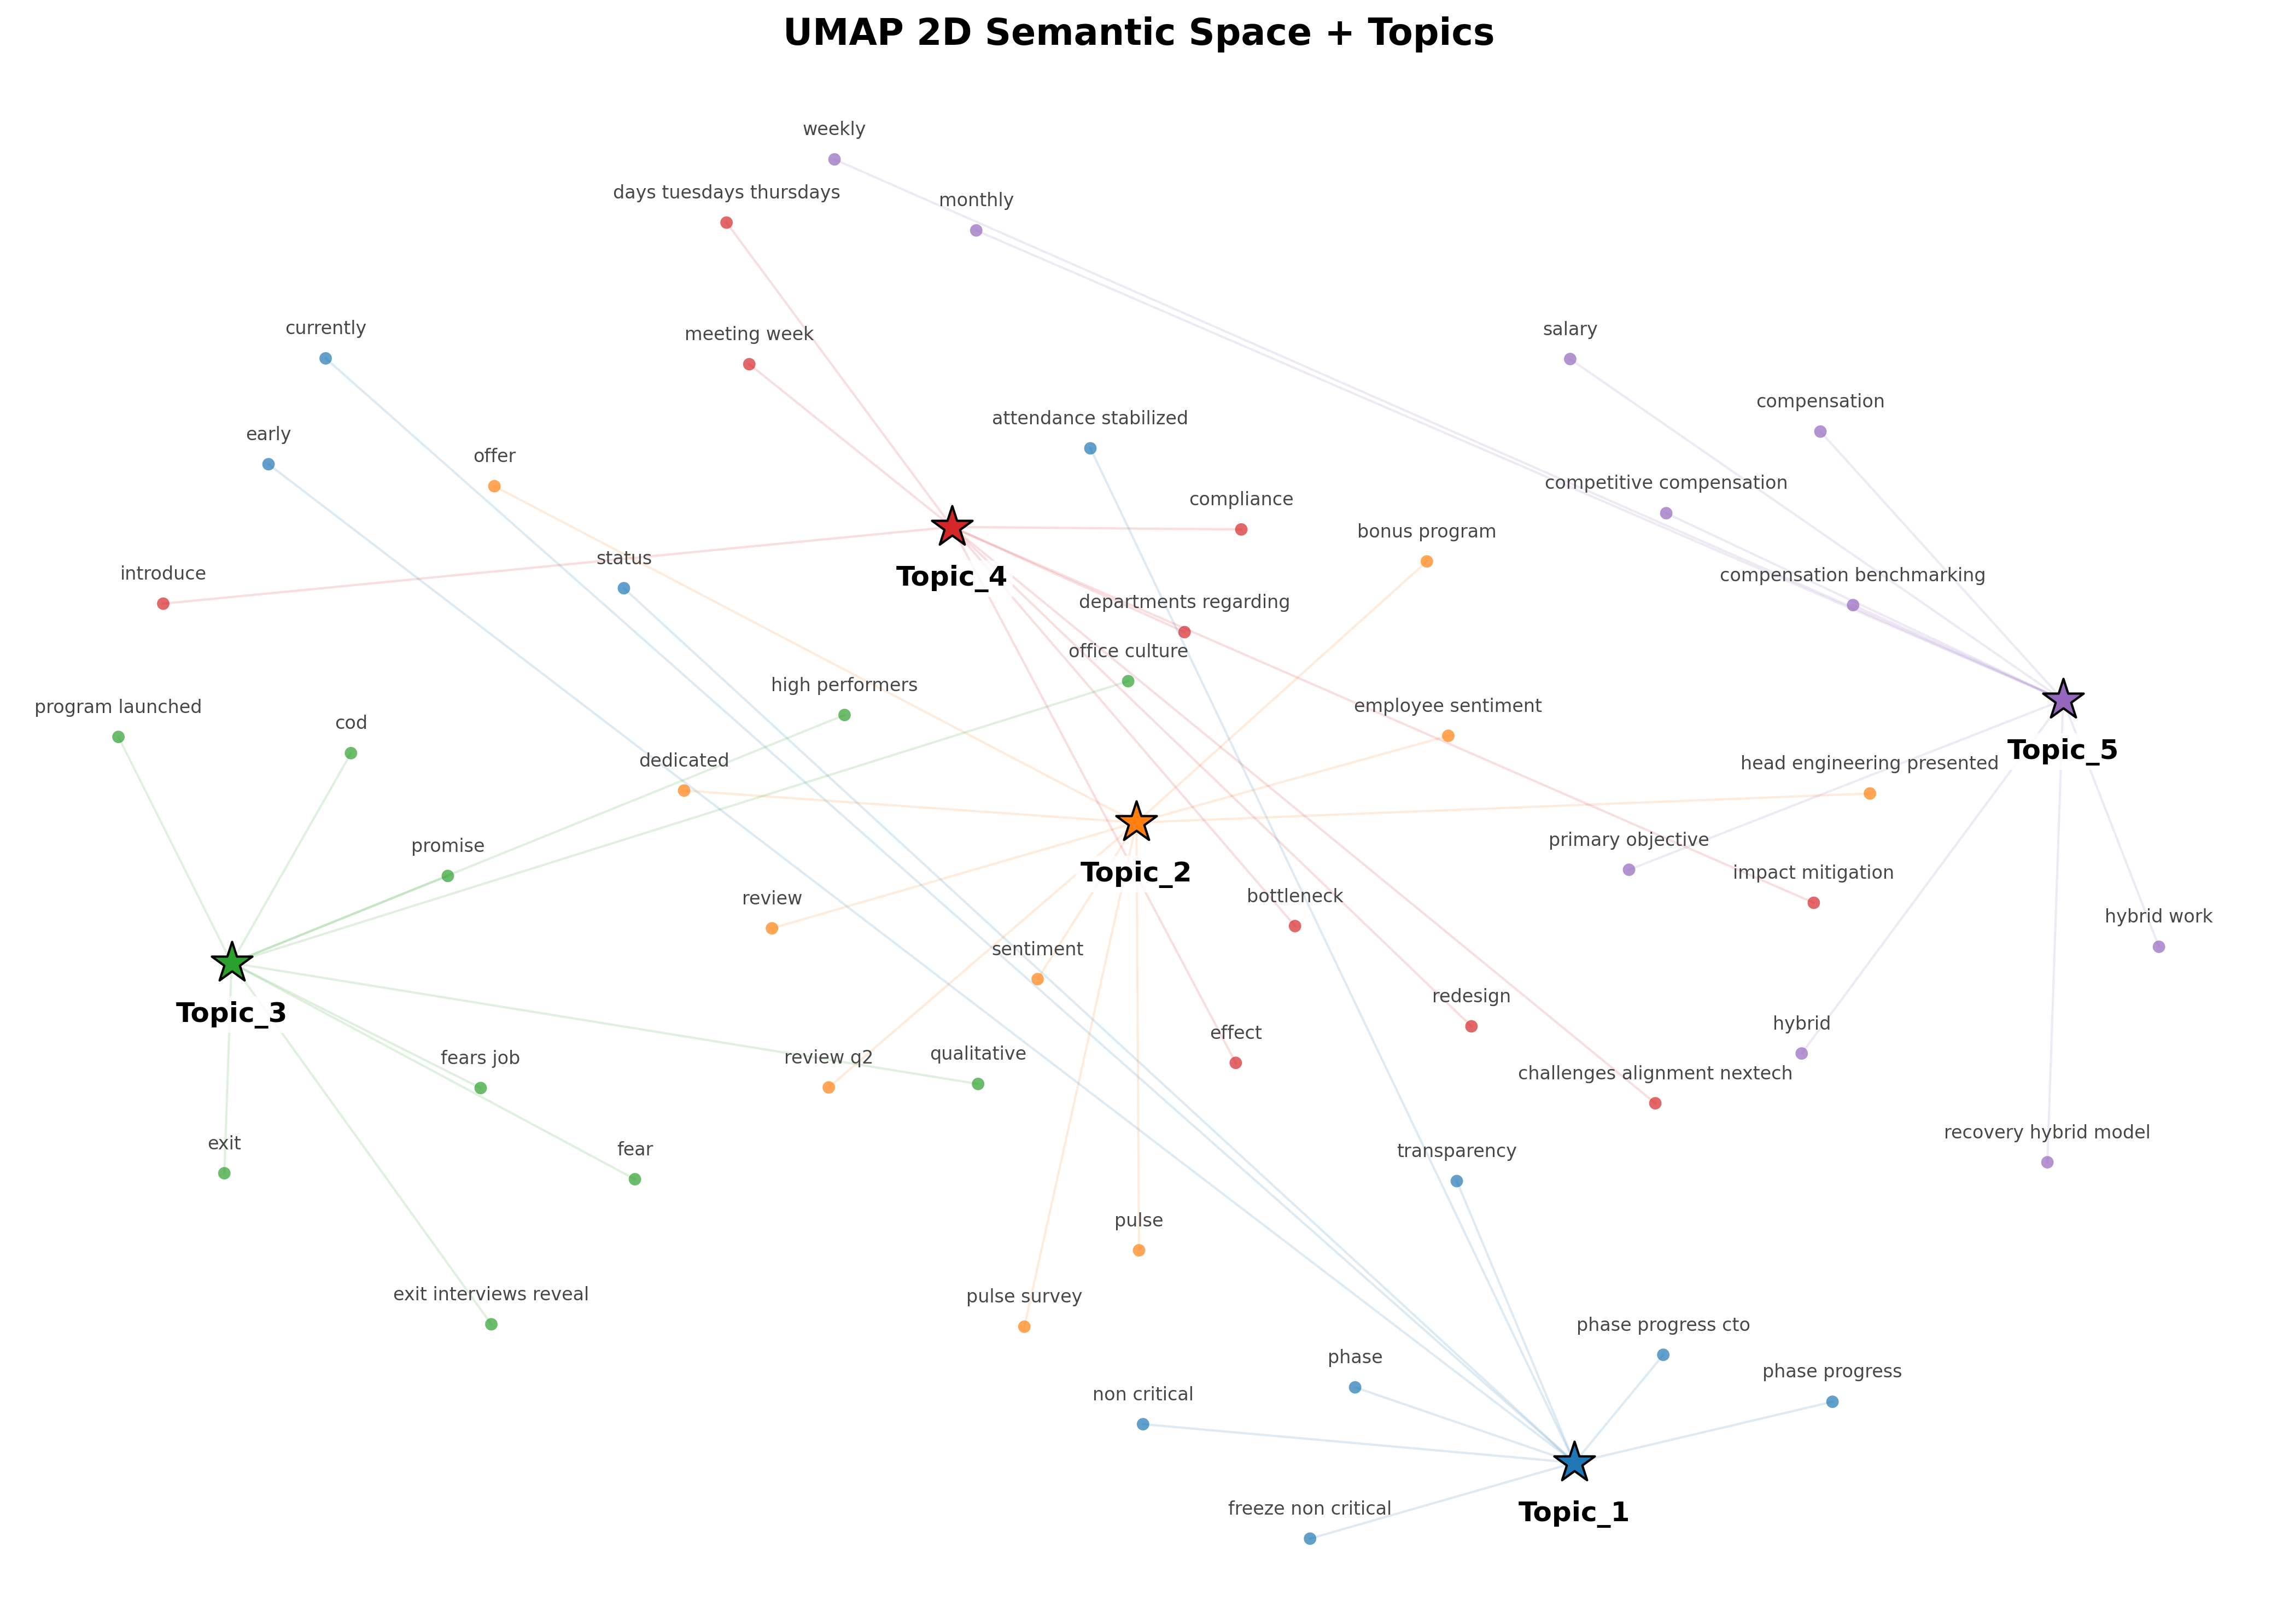

In [9]:
model.plot_training()         # loss + metric curves
#model.visualize_3d()          # interactive Plotly 3D
model.visualize_2d()          # high-res PNG for papers

In [10]:
model.get_topic_info()

 topic_id  size                                                                                    keywords
        1   210        week, senior, team, office, engineering, employee, role, developer, hire, leadership
        2    51 employee, retention, week, team, career, engineering, attrition, promotion, high, interview
        4    27    office, team, week, policy, day, employee, engineering, conflict, collaboration, commute
        5    20            week, senior, employee, review, retention, attrition, remain, office, team, hire
        3    17                 week, team, tool, integration, role, cto, adaptation, workforce, job, phase


,topic_id,size,keywords
0,1,210,"week, senior, team, office, engineering, emplo..."
1,2,51,"employee, retention, week, team, career, engin..."
2,4,27,"office, team, week, policy, day, employee, eng..."
3,5,20,"week, senior, employee, review, retention, att..."
4,3,17,"week, team, tool, integration, role, cto, adap..."


In [11]:
# Evaluation
metrics = model.evaluate()
print(metrics)




[Evaluation Summary]
  npmi_coherence        : -0.2781
  topic_diversity       : 0.92
  n_topics              : 5
{'npmi_coherence': -0.2781, 'topic_diversity': 0.92, 'n_topics': 5}
